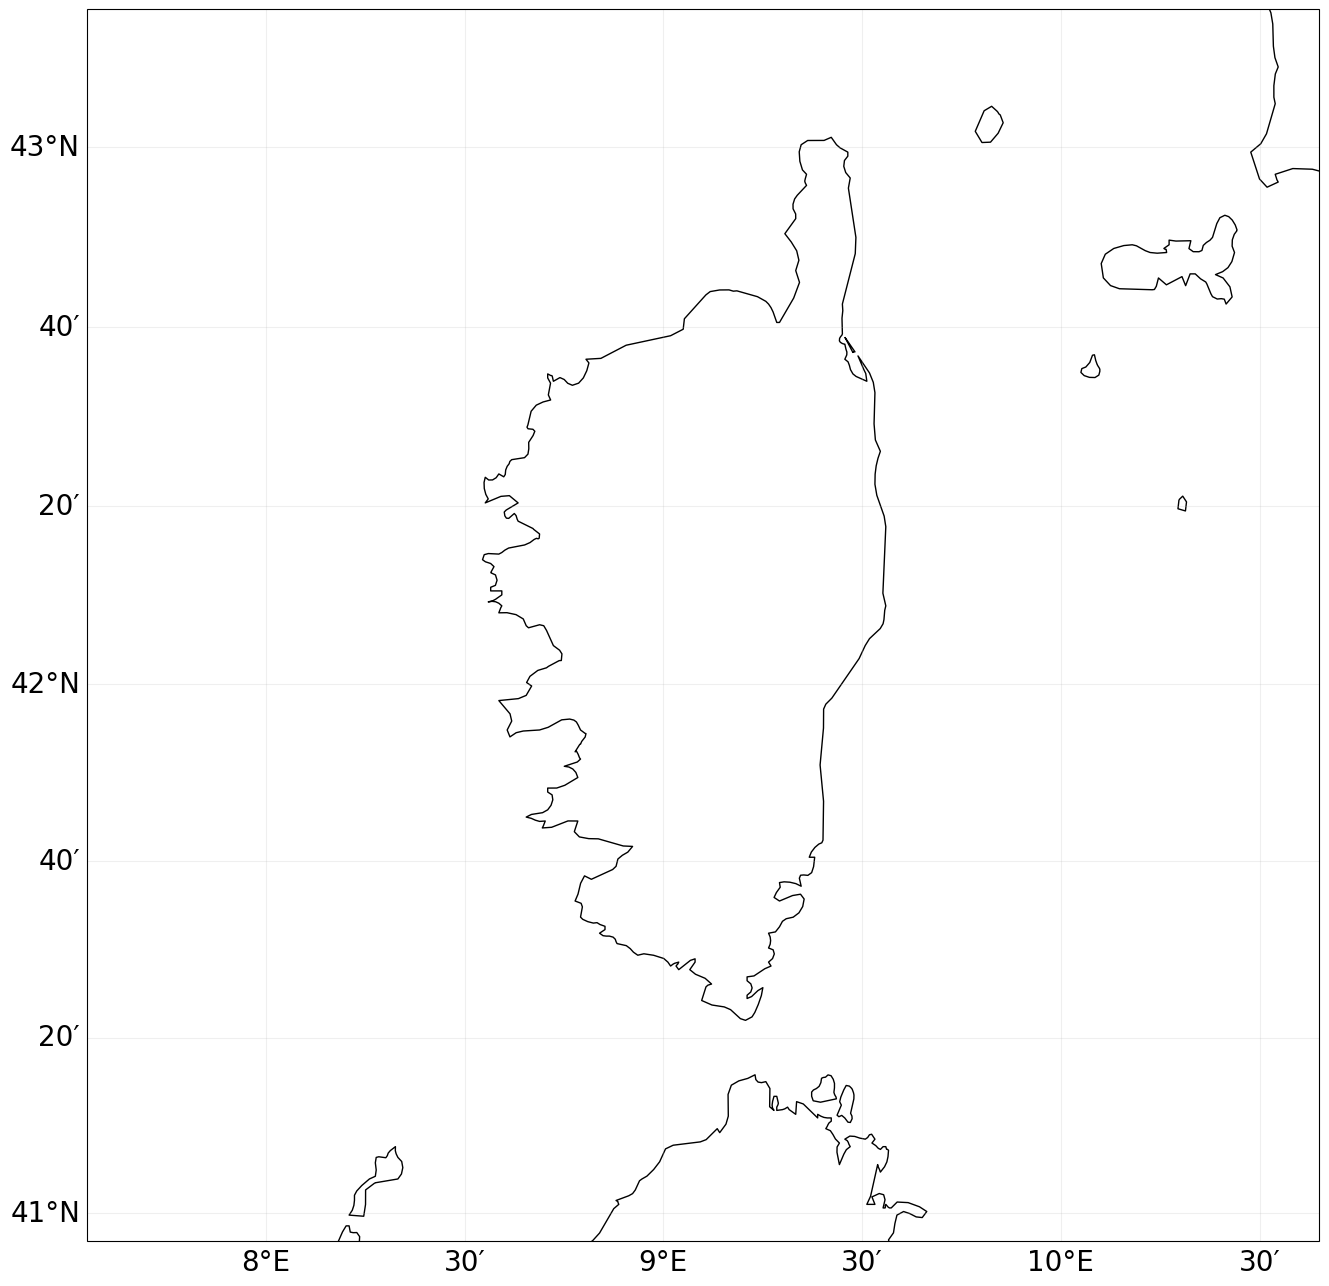

In [1]:
"""
This program displays the effective simulation domain based on the selected
parameters nx, ny, dx, dy, lon0, and lat0.
"""

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np


def plot_domain(lat0, lon0, nx, ny, dx, dy):
    """
    Display the effective simulation domain.

    Args:
        lat0 (float): Central latitude of the domain.
        lon0 (float): Central longitude of the domain.
        nx (int): Number of grid points along x.
        ny (int): Number of grid points along y.
        dx (int): Resolution along x in meters.
        dy (int): Resolution along y in meters.
    """

    # Check whether nx and ny are divisible by 2 or 3
    try:
        if nx % 2 != 0 and nx % 3 != 0 and nx % 5 != 0:
            raise ValueError("nx is not divisible by 2, 3 or 5")

        if ny % 2 != 0 and ny % 3 != 0 and ny % 5 != 0:
            raise ValueError("ny is not divisible by 2, 3 or 5")

    except ValueError as e:
        print(f"ERROR: {e}: please change its value")
        return

    # Constants (Earth radius in km)
    rt_pol = 6357
    rt_eq = 6378

    # Distance between degrees (km/degree)
    d_lat = 2 * np.pi * rt_pol / 360
    d_lon = 2 * np.pi * rt_eq / 360

    # Compute the limit of the domain in latitude and longitude
    latmin = lat0 - (0.5 * ny * dy / 1000) / d_lat
    latmax=lat0 + (0.5 * ny * dy / 1000) / d_lat
    lonmin=lon0 - (0.5 * nx * dx / 1000) / (d_lon * np.cos(np.deg2rad(lat0)))
    lonmax=lon0 + (0.5 * nx * dx / 1000) / (d_lon * np.cos(np.deg2rad(lat0)))

    # Plot the domaine with coastlines and borders
    plt.rcParams.update({'font.size': 20})
    plt.figure(figsize=(16, 16))
    projection = ccrs.Mercator()
    axes = plt.axes(projection=projection)
    axes.add_feature(cfeature.COASTLINE)
    axes.add_feature(cfeature.BORDERS)
    axes.set_extent((lonmin, lonmax, latmin, latmax))
    gl = axes.gridlines(
        draw_labels=True, 
        dms=True, 
        x_inline=False, 
        y_inline=False, 
        alpha=0.2
    )
    gl.top_labels = False
    gl.right_labels = False
    
    plt.show()


# Example for a domain around Corsica
plot_domain(42.1, 9.1, 512, 512, 500, 500)